# Homework 4

## Problem 3

### (a) Correlation between Climate Indices

**Calculate correlations among Nino 3.4, PDO, AMM, AMO, Hurricane Number, plus another two indices of your choice.**

Update: Some indices at NOAA/PSL website are out of maintenance. You can access hurricane number here: https://tropical.atmos.colostate.edu/Realtime/index.php?arch&loc=northatlantic 

In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Next we compute the correlation matrix

In [18]:
hurricane = pd.read_csv("data/hurricane_number.csv", header=0, index_col=0,  sep='\\s+', engine='python')
hurricane_num = hurricane["Hurricanes"]
amm = (pd.read_csv("data/amm.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
amo = (pd.read_csv("data/amo.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
pdo = (pd.read_csv("data/pdo.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
ao =  (pd.read_csv("data/ao.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
enso_precip = (pd.read_csv("data/enso_precp.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
nino = (pd.read_csv("data/nino3.4.csv", header=0, index_col=0,  sep='\\s+', engine='python')).mean(axis=1)
correlation = pd.DataFrame({"amm" : amm, "amo" : amo, "pdo" : pdo, "hurricane_num" : hurricane_num, "ao" : ao, "enso precipitatoin": enso_precip, "nino 3.4": nino}).dropna().corr()
print(correlation)

                         amm       amo       pdo  hurricane_num        ao  \
amm                 1.000000 -0.189768  0.288536      -0.005008  0.004650   
amo                -0.189768  1.000000 -0.272004       0.569140 -0.355524   
pdo                 0.288536 -0.272004  1.000000      -0.294670 -0.171069   
hurricane_num      -0.005008  0.569140 -0.294670       1.000000 -0.182270   
ao                  0.004650 -0.355524 -0.171069      -0.182270  1.000000   
enso precipitatoin  0.999418 -0.205527  0.308380      -0.026758  0.009275   
nino 3.4           -0.211950 -0.168143  0.498296      -0.425547  0.064576   

                    enso precipitatoin  nino 3.4  
amm                           0.999418 -0.211950  
amo                          -0.205527 -0.168143  
pdo                           0.308380  0.498296  
hurricane_num                -0.026758 -0.425547  
ao                            0.009275  0.064576  
enso precipitatoin            1.000000 -0.183894  
nino 3.4                  

We can visualize the result better using a heat map

Text(0.5, 1.0, 'Pearson Correlation Matrix Between Climate Indices')

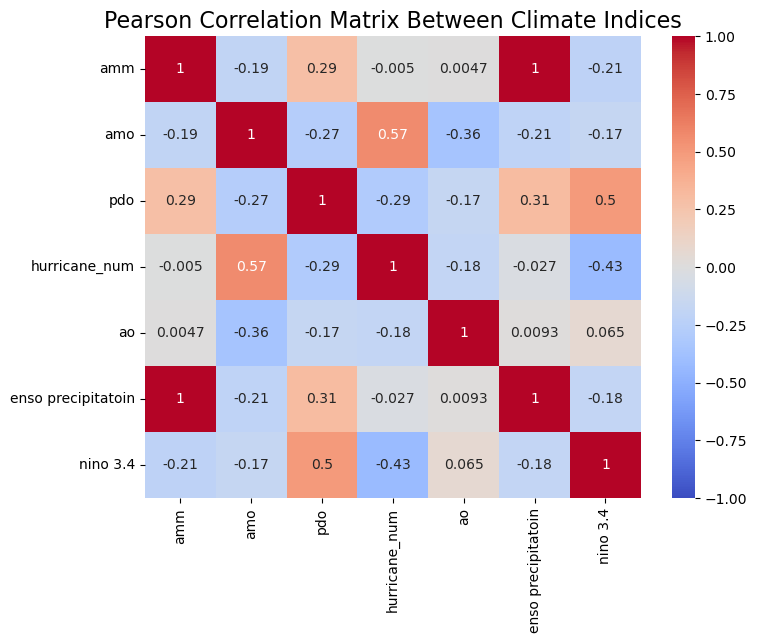

In [5]:
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix Between Climate Indices", fontsize=16, loc='center')

### (b) Climate Composite 

**Work with one index and rank its values. Identify the years with most positive and most negative values. Plot climate composites using precipitation data**


:::{tip}
I'll choose **Nino 3.4* as my index.
:::

high nino index years 1948
1997    1.115000
1987    1.094167
1982    0.831667
2023    0.824167
1972    0.670000
dtype: float64
low nino index years 1948
1955   -1.445000
1950   -1.349167
1975   -1.316667
1999   -1.286667
1971   -1.236667
dtype: float64


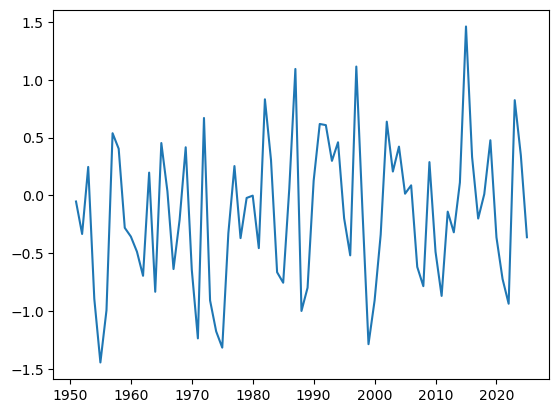

In [19]:
fig, ax = plt.subplots() 
ax.plot(nino.index[2:len(nino)-1], nino.to_numpy()[2:len(nino)-1])
nino_sorted=nino.sort_values()[2:-1]
print(f"high nino index years {nino_sorted[::-1][0:5]}")
print(f"low nino index years {nino_sorted[0:5:1]}")


Let's download the precipitation data that correspond to the lowest/highest *amm index* years.

In [20]:
import cdsapi

dataset = "reanalysis-era5-single-levels-monthly-means"
request = {
    "product_type": ["monthly_averaged_reanalysis"],
    "variable": ["total_precipitation"],
    "year": [
        "1997", "1987", "1982", '2023', '1972',
        "1955", "1950", "1975", '1999', '1971'
    ],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "time": ["00:00"],
    "data_format": "grib",
    "download_format": "unarchived"
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()


2026-03-13 13:33:10,419 INFO Request ID is dab5dfbf-2bd1-4159-acd5-26f8c03e409a
2026-03-13 13:33:10,596 INFO status has been updated to accepted
2026-03-13 13:33:24,854 INFO status has been updated to running
2026-03-13 13:33:44,177 INFO status has been updated to successful


'cb52ca80b61b573c48613b89e153a9dc.grib'

Again using my library **climavis**, we can do some visualization:

('time', 'latitude', 'longitude')
scalar
[Visualize-LOG] Directory 'output/yearly_total_precipitation' already exists
[Visualize-LOG] Directory 'output/yearly_total_precipitation/frame' already exists
[Visualize-LOG] Directory 'output/yearly_total_precipitation/animation' already exists
[Visualize LOG] Plotting frame in scalar mode


100%|██████████| 2/2 [00:05<00:00,  2.61s/it]


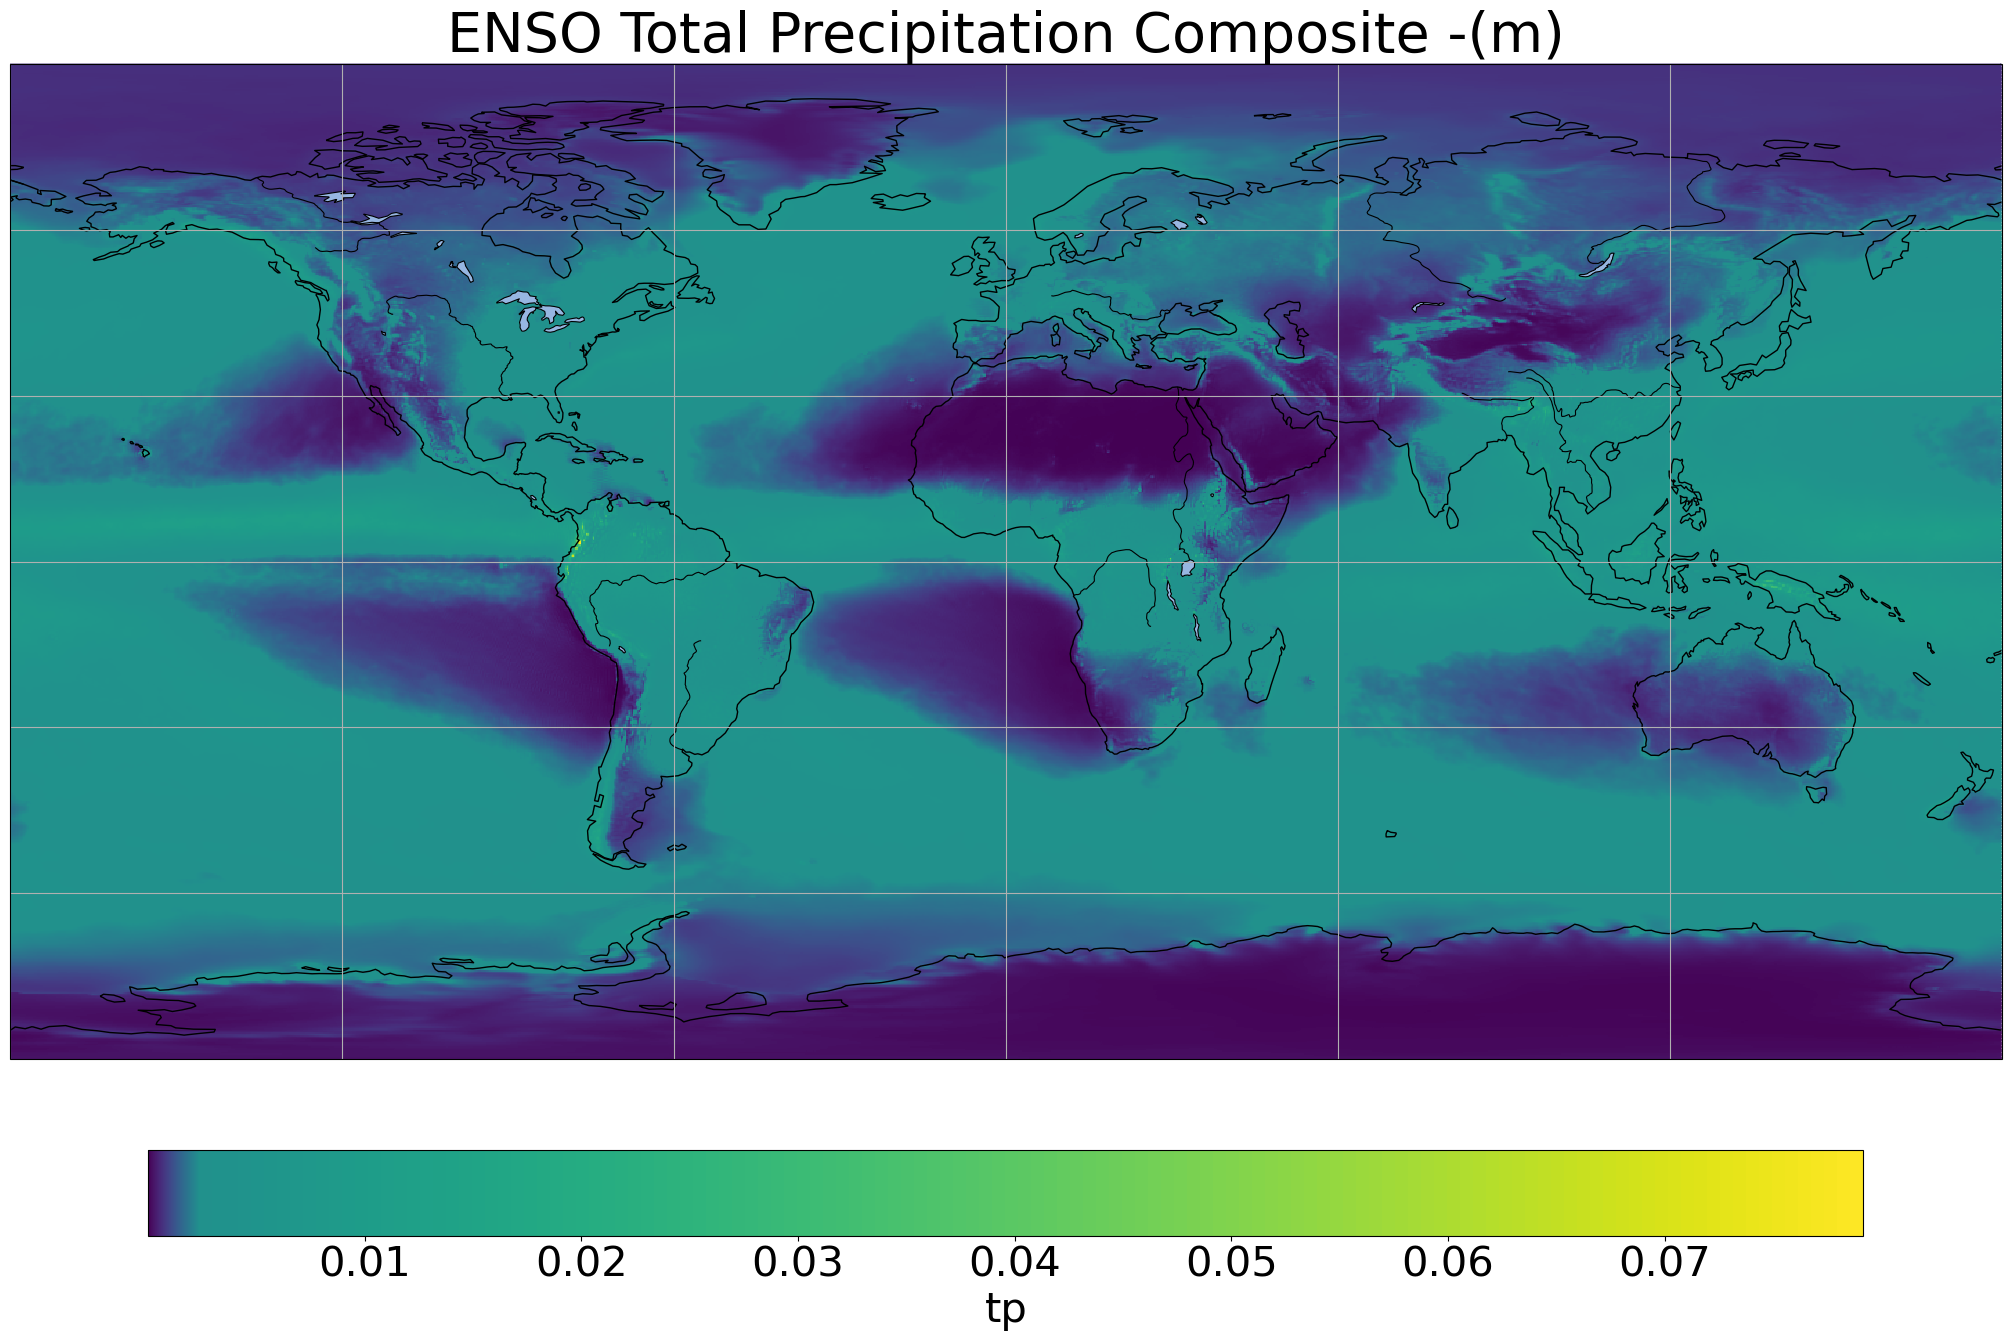

In [1]:
import climavis as cv
data_path = {
    "tp" : "data/precipitation.grib" 
}

ds_tp = cv.DataSet("total precipitation", data_paths = data_path, time_steps=120, unit='m')

intervals = [(12 * i, 12 * (i + 1)) for i in range(10)]

ds_tp.averageOverTime(intervals, new_time_unit='years', new_time_steps=10, new_time_sequence=[
        "1997", "1987", "1982", '2023', '1972',
        "1955", "1950", "1975", '1999', '1971'
    ])

print(ds_tp.S['tp'].dims)

second_intervals = [(0, 5), (5, 10)]
ds_tp.averageOverTime(intervals=second_intervals, new_time_steps=2, new_time_sequence=['+', '-'])

vis_param = {
    "task_name" : "yearly_total_precipitation",
    "data_set" : ds_tp, 
    "outputs_dir" : "output"
}

print(ds_tp.mode)

vis = cv.Visualize(**vis_param)
vis.populate_frame(title="ENSO Total Precipitation Composite")